## Code Implementation

In [1]:
import numpy as np
from PIL import Image
from scipy.fftpack import dct, idct

In [5]:
def message_to_binary(message):
    binary_message = ""
    for char in message:
        binary_message += format(ord(char), '08b')
    binary_message += format(0, '08b')  
    return binary_message

def binary_to_message(binary_data):
    message = ""
    for i in range(0, len(binary_data), 8):
        byte = binary_data[i:i+8]
        if len(byte) < 8: break
        char_code = int(byte, 2)
        if char_code == 0: break
        message += chr(char_code)
    return message

def encode_dct(image_path, secret_message, output_path, step=20):
    img = Image.open(image_path).convert('RGB')
    width, height = img.size
    
    width = (width // 8) * 8
    height = (height // 8) * 8
    img = img.resize((width, height))
    
    img_array = np.array(img, dtype=float)
    r_channel = img_array[:, :, 0]
    
    binary_msg = message_to_binary(secret_message)
    msg_index = 0
    msg_len = len(binary_msg)
    
    for y in range(0, height, 8):
        for x in range(0, width, 8):
            if msg_index >= msg_len: break
                
            block = r_channel[y:y+8, x:x+8]
            dct_block = dct(dct(block.T, norm='ortho').T, norm='ortho')
            
            coeff = dct_block[4, 4]
            bit = int(binary_msg[msg_index])
            
            if bit == 0:
                coeff = np.floor(coeff / step) * step + (step / 4)
            else:
                coeff = np.floor(coeff / step) * step + (3 * step / 4)
                
            dct_block[4, 4] = coeff
            msg_index += 1
            
            idct_block = idct(idct(dct_block.T, norm='ortho').T, norm='ortho')
            r_channel[y:y+8, x:x+8] = idct_block
            
        if msg_index >= msg_len: break
            
    img_array[:, :, 0] = r_channel
    modified_img = Image.fromarray(np.uint8(np.clip(img_array, 0, 255)))
    modified_img.save(output_path, "PNG")
    print(f"Message robustly hidden in {output_path}!")

def decode_dct(image_path, step=20):
    img = Image.open(image_path).convert('RGB')
    width, height = img.size
    
    img_array = np.array(img, dtype=float)
    r_channel = img_array[:, :, 0]
    
    binary_data = ""
    
    for y in range(0, height, 8):
        for x in range(0, width, 8):
            block = r_channel[y:y+8, x:x+8]
            dct_block = dct(dct(block.T, norm='ortho').T, norm='ortho')
            
            coeff = dct_block[4, 4]
            remainder = coeff % step
            if remainder < (step / 2):
                binary_data += "0"
            else:
                binary_data += "1"
                
            if len(binary_data) % 8 == 0:
                last_byte = binary_data[-8:]
                if int(last_byte, 2) == 0:
                    return binary_to_message(binary_data)
                    
    return binary_to_message(binary_data)

# --- Example Usage ---
if __name__ == "__main__":
    STEP_SIZE = 25 
    
    encode_dct("input_image.jpg", "DCT steganography is done successfully!", "dct_encoded.png", step=STEP_SIZE)
    recovered_text = decode_dct("dct_encoded.png", step=STEP_SIZE)
    print(f"Decoded Text: {recovered_text}")

Message robustly hidden in dct_encoded.png!
Decoded Text: DCT steganography is done successfully!


## Image Plotting

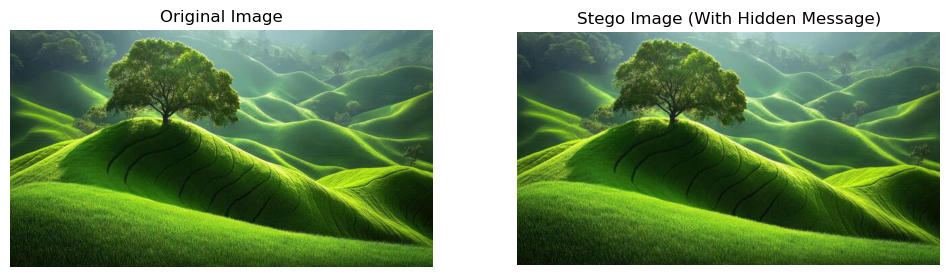

In [3]:
import matplotlib.pyplot as plt

# Load both images
original = Image.open("input_image.jpg")
stego = Image.open("dct_encoded.png")

# Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(stego)
axes[1].set_title("Stego Image (With Hidden Message)")
axes[1].axis('off')

plt.show()

In [8]:
! git reset 

In [10]:
! git log --oneline

fatal: your current branch 'master' does not have any commits yet


In [11]:
!git checkout master

error: pathspec 'master' did not match any file(s) known to git
